In [90]:
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split



In [91]:
cars = pd.read_csv("cars_raw.csv")
cars.head()


,Year,Make,Model,Used/New,Price,ConsumerRating,ConsumerReviews,SellerType,SellerName,SellerRating,...,InteriorColor,Drivetrain,MinMPG,MaxMPG,FuelType,Transmission,Engine,VIN,Stock#,Mileage
0,2019,Toyota,Sienna SE,Used,"$39,998",4.6,45,Dealer,CarMax Murrieta - Now offering Curbside Pickup...,3.3,...,Black,Front-wheel Drive,19,27,Gasoline,8-Speed Automatic,3.5L V6 24V PDI DOHC,5TDXZ3DC2KS015402,22998646,29403
1,2018,Ford,F-150 Lariat,Used,"$49,985",4.8,817,Dealer,Giant Chevrolet,4.8,...,Black,Four-wheel Drive,19,24,Gasoline,10-Speed Automatic,3.5L V6 24V PDI DOHC Twin Turbo,1FTEW1EG2JFD44217,22418A,32929
2,2017,RAM,1500 Laramie,Used,"$41,860",4.7,495,Dealer,Gill Auto Group Madera,4.6,...,Black,Four-wheel Drive,15,21,Gasoline,8-Speed Automatic,5.7L V8 16V MPFI OHV,1C6RR7VT5HS842283,NG277871G,23173
3,2021,Honda,Accord Sport SE,Used,"$28,500",5.0,36,Dealer,AutoSavvy Las Vegas,4.6,...,–,Front-wheel Drive,29,35,Gasoline,Automatic CVT,1.5L I4 16V GDI DOHC Turbo,1HGCV1F49MA038035,54237,10598
4,2020,Lexus,RX 350,Used,"$49,000",4.8,76,Dealer,Lexus of Henderson,4.8,...,Birch,Front-wheel Drive,20,27,Gasoline,8-Speed Automatic,3.5L V6 24V PDI DOHC,2T2AZMAA8LC156270,HDT4181A,28137


In [92]:
#limpieza de datos

df = pd.read_csv('cars_raw.csv')

df['Price']  = pd.to_numeric(df['Price'].str.replace(r'[$,]', '', regex=True), errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Year']    = pd.to_numeric(df['Year'], errors='coerce')
df['MinMPG']  = pd.to_numeric(df['MinMPG'], errors='coerce')
df['MaxMPG']  = pd.to_numeric(df['MaxMPG'], errors='coerce')

df['Used/New'] = df['Used/New'].apply(lambda x: 'Used' if x == 'Used' else 'New')

df['FuelType_enc']     = df['FuelType'].astype('category').cat.codes
df['Transmission_enc'] = df['Transmission'].astype('category').cat.codes
df['Drivetrain_enc']   = df['Drivetrain'].astype('category').cat.codes
df['Make_enc']         = df['Make'].astype('category').cat.codes

df = df.dropna(subset=['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating', 'Used/New', 'MinMPG', 'MaxMPG'])

nuevo_auto = [[2020, 25000, 15000, 4.5, 4.0]]

In [93]:
#Clasificacion
#Suport Vectors

X = df[['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating']].values
y = df['Used/New'].values

# Split y entrenar SVC
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearSVC(C=1.0, max_iter=2000)
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)

# Predecir un auto real
print(f"Predicción: {model.predict(nuevo_auto)}")
#Mostrar accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Predicción: ['Used']
Accuracy: 0.8218666666666666


In [94]:
#K-Nearest neighbors

X = df[['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating']].values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

y = df['Used/New'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Predicción: {knn.predict(nuevo_auto)}")
print(f"Accuracy: {accuracy:.2f}")


Predicción: ['Used']
Accuracy: 0.78


In [95]:
#Naive Bayes Model


X = df[['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating']].values
y = df['Used/New'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model_GNB = GaussianNB()

model_GNB.fit(X_train, y_train)

y_pred = model_GNB.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Predicción: {model_GNB.predict(nuevo_auto)}")
print(f"\nModel Accuracy: {accuracy:.4f}")

Predicción: ['Used']

Model Accuracy: 0.7540


In [96]:
##REGRESION MODELS

#Linear Regression
#Predice precio de un auto basado en sus caracteristicas

X = df[['Year', 'Mileage', 'ConsumerRating', 'SellerRating', 
        'FuelType_enc', 'Transmission_enc', 'Drivetrain_enc', 
        'Make_enc', 'MinMPG', 'MaxMPG']].values
y = df['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model_LR = LinearRegression()
model_LR.fit(X_train, y_train)

y_pred = model_LR.predict(X_test)

nuevo_auto2 = [[2020, 15000, 4.5, 4.0, 1, 1, 1, 10, 25, 32]]
print(f"\nPrecio estimado: ${model_LR.predict(nuevo_auto2)[0]:,.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")


Precio estimado: $61,255.89
R²:   0.2200


In [97]:
#Polinomial Regression

X = df[['Year', 'Mileage', 'ConsumerRating', 'SellerRating']].values
y = df['Price'].values

poly = PolynomialFeatures(degree=3, include_bias=True)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

model_PR = LinearRegression()
model_PR.fit(X_train, y_train)

y_pred = model_PR.predict(X_test)
r2   = r2_score(y_test, y_pred)

nuevo_auto3 = np.array([[2020, 15000, 4.5, 4.0]])
nuevo_auto_poly = poly.transform(nuevo_auto3) 
precio_pred = model_PR.predict(nuevo_auto_poly)
print(f"\nPrecio estimado: ${precio_pred[0]:,.2f}")
print(f"R²:   {r2:.4f}")


Precio estimado: $48,931.45
R²:   0.1490


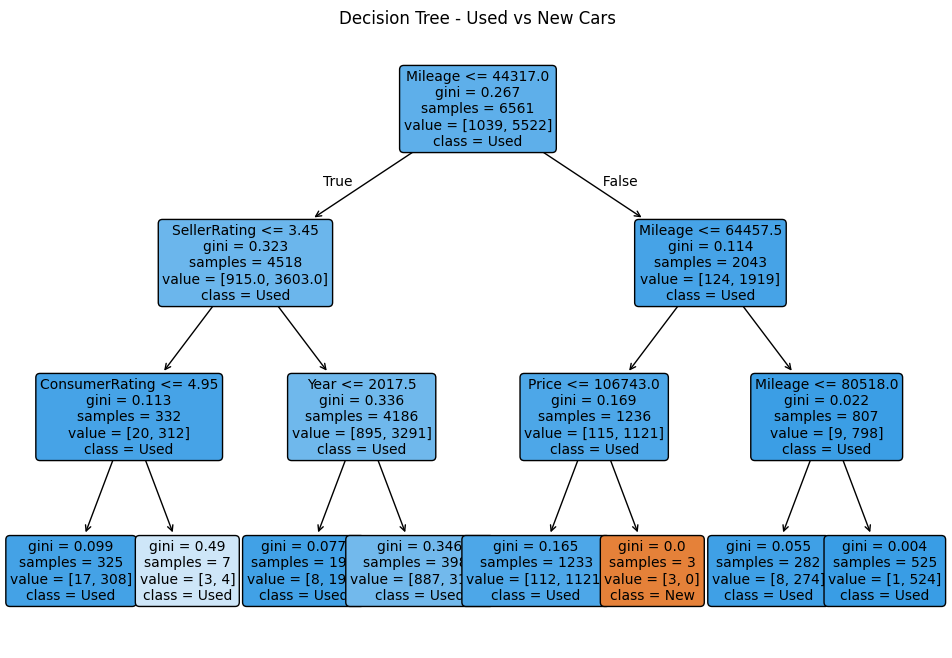


Predicción: ['Used']

Accuracy: 0.8439


In [98]:
## Versatile and advanced models

#Decision Trees

features = ['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating']
X = df[features].values
y = df['Used/New'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


#Ver el árbol
class_names = list(clf.classes_)

plt.figure(figsize=(12, 8))
tree.plot_tree(clf,
               feature_names=features,
               class_names=class_names,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title("Decision Tree - Used vs New Cars")
plt.show()

print(f"\nPredicción: {clf.predict(nuevo_auto)}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

In [99]:
#Random forest
features = ['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating']
X = df[features].values
y = df['Used/New'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]


accuracy = accuracy_score(y_test, y_pred)
print(f"\nPredicción: {rf_model.predict(nuevo_auto)}")
print(f'\nModel Accuracy: {accuracy * 100:.2f}%')


Predicción: ['New']

Model Accuracy: 85.33%


In [100]:
#Neural Networks
features = ['Year', 'Price', 'Mileage', 'ConsumerRating', 'SellerRating']
X = df[features].values.astype(np.float32)
y_raw = df['Used/New'].values

encoder = LabelEncoder()
y = encoder.fit_transform(y_raw) 
X = (X - X.mean(axis=0)) / X.std(axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_NN = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(len(features),)), 
    layers.Dense(64, activation='relu'),                                
    layers.Dense(1, activation='sigmoid')                                
])

model_NN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_NN.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

loss, accuracy = model_NN.evaluate(X_test, y_test, verbose=0)

nuevo_auto_NN = np.array([[2020, 25000, 15000, 4.5, 4.0]], dtype=np.float32)
nuevo_auto_NN = (nuevo_auto_NN - df[features].values.mean(axis=0)) / df[features].values.std(axis=0)

prob = model_NN.predict(nuevo_auto_NN)[0][0]
clase = encoder.classes_[int(prob > 0.5)]
print(f"Test Loss:     {loss:.4f}")
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"\nPredicción: {clase} (probabilidad: {prob:.4f})")

Epoch 1/20


C:\Users\edgar\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8452 - loss: 0.4041 - val_accuracy: 0.8520 - val_loss: 0.3748
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3891 - val_accuracy: 0.8520 - val_loss: 0.3734
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3857 - val_accuracy: 0.8520 - val_loss: 0.3714
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3853 - val_accuracy: 0.8520 - val_loss: 0.3717
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3840 - val_accuracy: 0.8520 - val_loss: 0.3703
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3824 - val_accuracy: 0.8520 - val_loss: 0.3727
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3822 - val_accuracy: 0.8520 - val_loss: 0.3708
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3807 - val_accuracy: 0.8520 - val_